# Fashion MNIST

Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

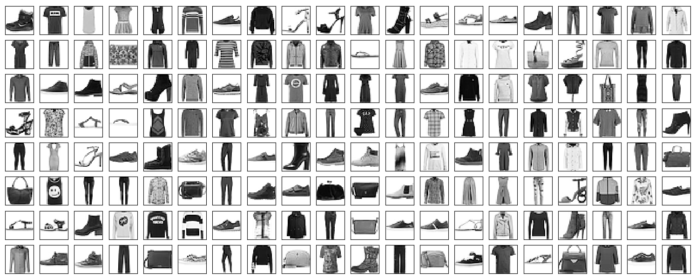


## 데이터 로드

In [1]:
import tensorflow as tf

In [18]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

### 데이터 shape 확인

In [3]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


### 이미지 출력 
#### 5 x 5로 이미지 출력
#### cmap='gray_r'  

In [4]:
import matplotlib.pyplot as plt

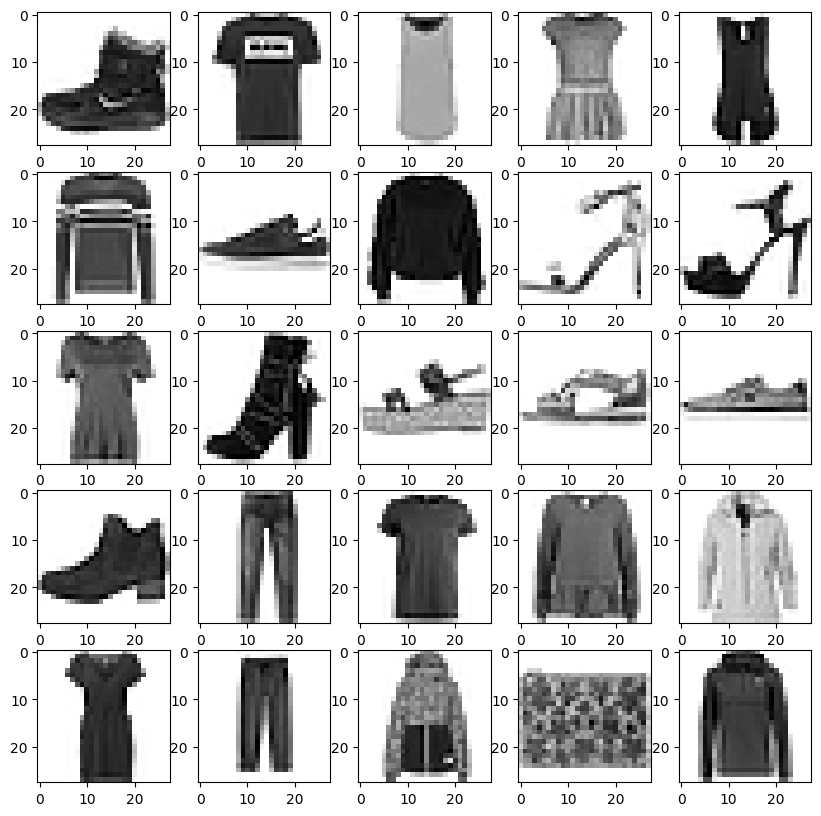

In [5]:
fig, axs = plt.subplots(5,5, figsize=(10, 10))
for i in range(5):
  for j in range(5):
    axs[i, j].imshow(x_train[i*5+j], cmap='gray_r')
plt.show()


## class 확인

In [19]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker', 
         8:'Bag', 9:'Ankel boot'}

In [8]:
y_train[0:25]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9, 1, 0, 6, 4, 3, 1,
       4, 8, 4], dtype=uint8)

In [20]:
print([items[i] for i in y_train[0:25]])

['Ankel boot', 'T-shirt/top', 'T-shirt/top', 'Dress', 'T-shirt/top', 'Pullover', 'Sneaker', 'Pullover', 'Sandal', 'Sandal', 'T-shirt/top', 'Ankel boot', 'Sandal', 'Sandal', 'Sneaker', 'Ankel boot', 'Trouser', 'T-shirt/top', 'Shirt', 'Coat', 'Dress', 'Trouser', 'Coat', 'Bag', 'Coat']


In [21]:
import numpy as np

In [27]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [28]:
print([items[i] for i in np.unique(y_train)])

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankel boot']


## 검증데이터(validation data) 생성

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
# 학습 데이터에서 검증 데이터로 20%를 분리
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [33]:
# train : 48,000개, 모델 학습 용
# val : 12,000개, 모델 평가 용
# test : 10,000개, 모델 최종 평가 용
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(48000, 28, 28) (48000,)
(12000, 28, 28) (12000,)
(10000, 28, 28) (10000,)


## one-hot encoding

In [ ]:
# 원-핫 인코딩
# 0 ~ 9 사이의 정수로 표현된 레이블을 10차원의 벡터로 변환
# 다중 클래스 분류 문제에서 모델이 각 클래스에 대한 확률을 출력하도록 하기 위해
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_val = tf.keras.utils.to_categorical(y_val, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [35]:
print(y_train.shape, y_val.shape, y_test.shape)

(48000, 10) (12000, 10) (10000, 10)


## 정규화(Normalization)

In [36]:
# 픽셀 값 정규화
# 픽셀 값은 0 ~ 255 사이의 정수로 표현되므로, 
# 이를 0 ~ 1 사이의 실수로 변환하여 모델 학습을 안정화하고 성능을 향상
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

In [37]:
print(x_val[0:10])

[[[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.00784314 0.         0.43921569 ... 0.         0.         0.00392157]
  [0.00784314 0.         0.08235294 ... 0.         0.00392157 0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.      

## 직렬화

In [38]:
# 신경망 모델은 일반적으로 1차원 벡터 형태의 입력을 받으므로,
# 28xs28 크기의 이미지를 784(=28*28) 차원의 벡터로 변환
x_train = x_train.reshape(-1, 28*28)
x_val = x_val.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [39]:
print(x_train.shape, x_val.shape, x_test.shape)

(48000, 784) (12000, 784) (10000, 784)


## model 생성

In [40]:
from tensorflow.keras import layers, models

In [74]:
model = models.Sequential([
    layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')  
])

In [60]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## 학습

In [76]:
# 모델 학습
# 학습 데이터(x_train, y_train)를 사용하여 모델을 학습하고,
# 검증 데이터(x_val, y_val)를 사용하여 각 epoch마다 모델의 성능을 평가
history = model.fit(x_train, y_train, epochs=30, validation_data=(x_val, y_val))

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 708us/step - accuracy: 0.7970 - loss: 0.5661 - val_accuracy: 0.8488 - val_loss: 0.4098
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step - accuracy: 0.8539 - loss: 0.3969 - val_accuracy: 0.8622 - val_loss: 0.3791
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 632us/step - accuracy: 0.8696 - loss: 0.3569 - val_accuracy: 0.8494 - val_loss: 0.4103
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 618us/step - accuracy: 0.8775 - loss: 0.3329 - val_accuracy: 0.8702 - val_loss: 0.3532
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 693us/step - accuracy: 0.8837 - loss: 0.3132 - val_accuracy: 0.8702 - val_loss: 0.3603
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 608us/step - accuracy: 0.8892 - loss: 0.2961 - val_accuracy: 0.8758 - val_loss: 0.3435
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 589us/step - accuracy: 0.8951 - loss: 0.2821 - val_accuracy: 0.8821 - val_loss: 0.3243
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 930us/step - accuracy: 0.8978 -

In [77]:
history.history

{'accuracy': [0.7969791889190674,
  0.8538958430290222,
  0.8695833086967468,
  0.8775416612625122,
  0.8836874961853027,
  0.8892291784286499,
  0.8950833082199097,
  0.8978124856948853,
  0.9027708172798157,
  0.9054791927337646,
  0.9090416431427002,
  0.9125208258628845,
  0.9153749942779541,
  0.9186875224113464,
  0.9209583401679993,
  0.9237083196640015,
  0.9256458282470703,
  0.9280416369438171,
  0.929520845413208,
  0.9323750138282776,
  0.9340000152587891,
  0.9338750243186951,
  0.9379166960716248,
  0.940833330154419,
  0.9416875243186951,
  0.9418541789054871,
  0.9434166550636292,
  0.9459375143051147,
  0.9466666579246521,
  0.9494791626930237],
 'loss': [0.5660586953163147,
  0.3969389796257019,
  0.35688382387161255,
  0.33285441994667053,
  0.3132382333278656,
  0.296106219291687,
  0.2821129262447357,
  0.26875802874565125,
  0.258743017911911,
  0.2489771693944931,
  0.2410786747932434,
  0.23273447155952454,
  0.2236119657754898,
  0.21700386703014374,
  0.209088

In [78]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 363us/step - accuracy: 0.8846 - loss: 0.4028


[0.4027658998966217, 0.8845999836921692]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


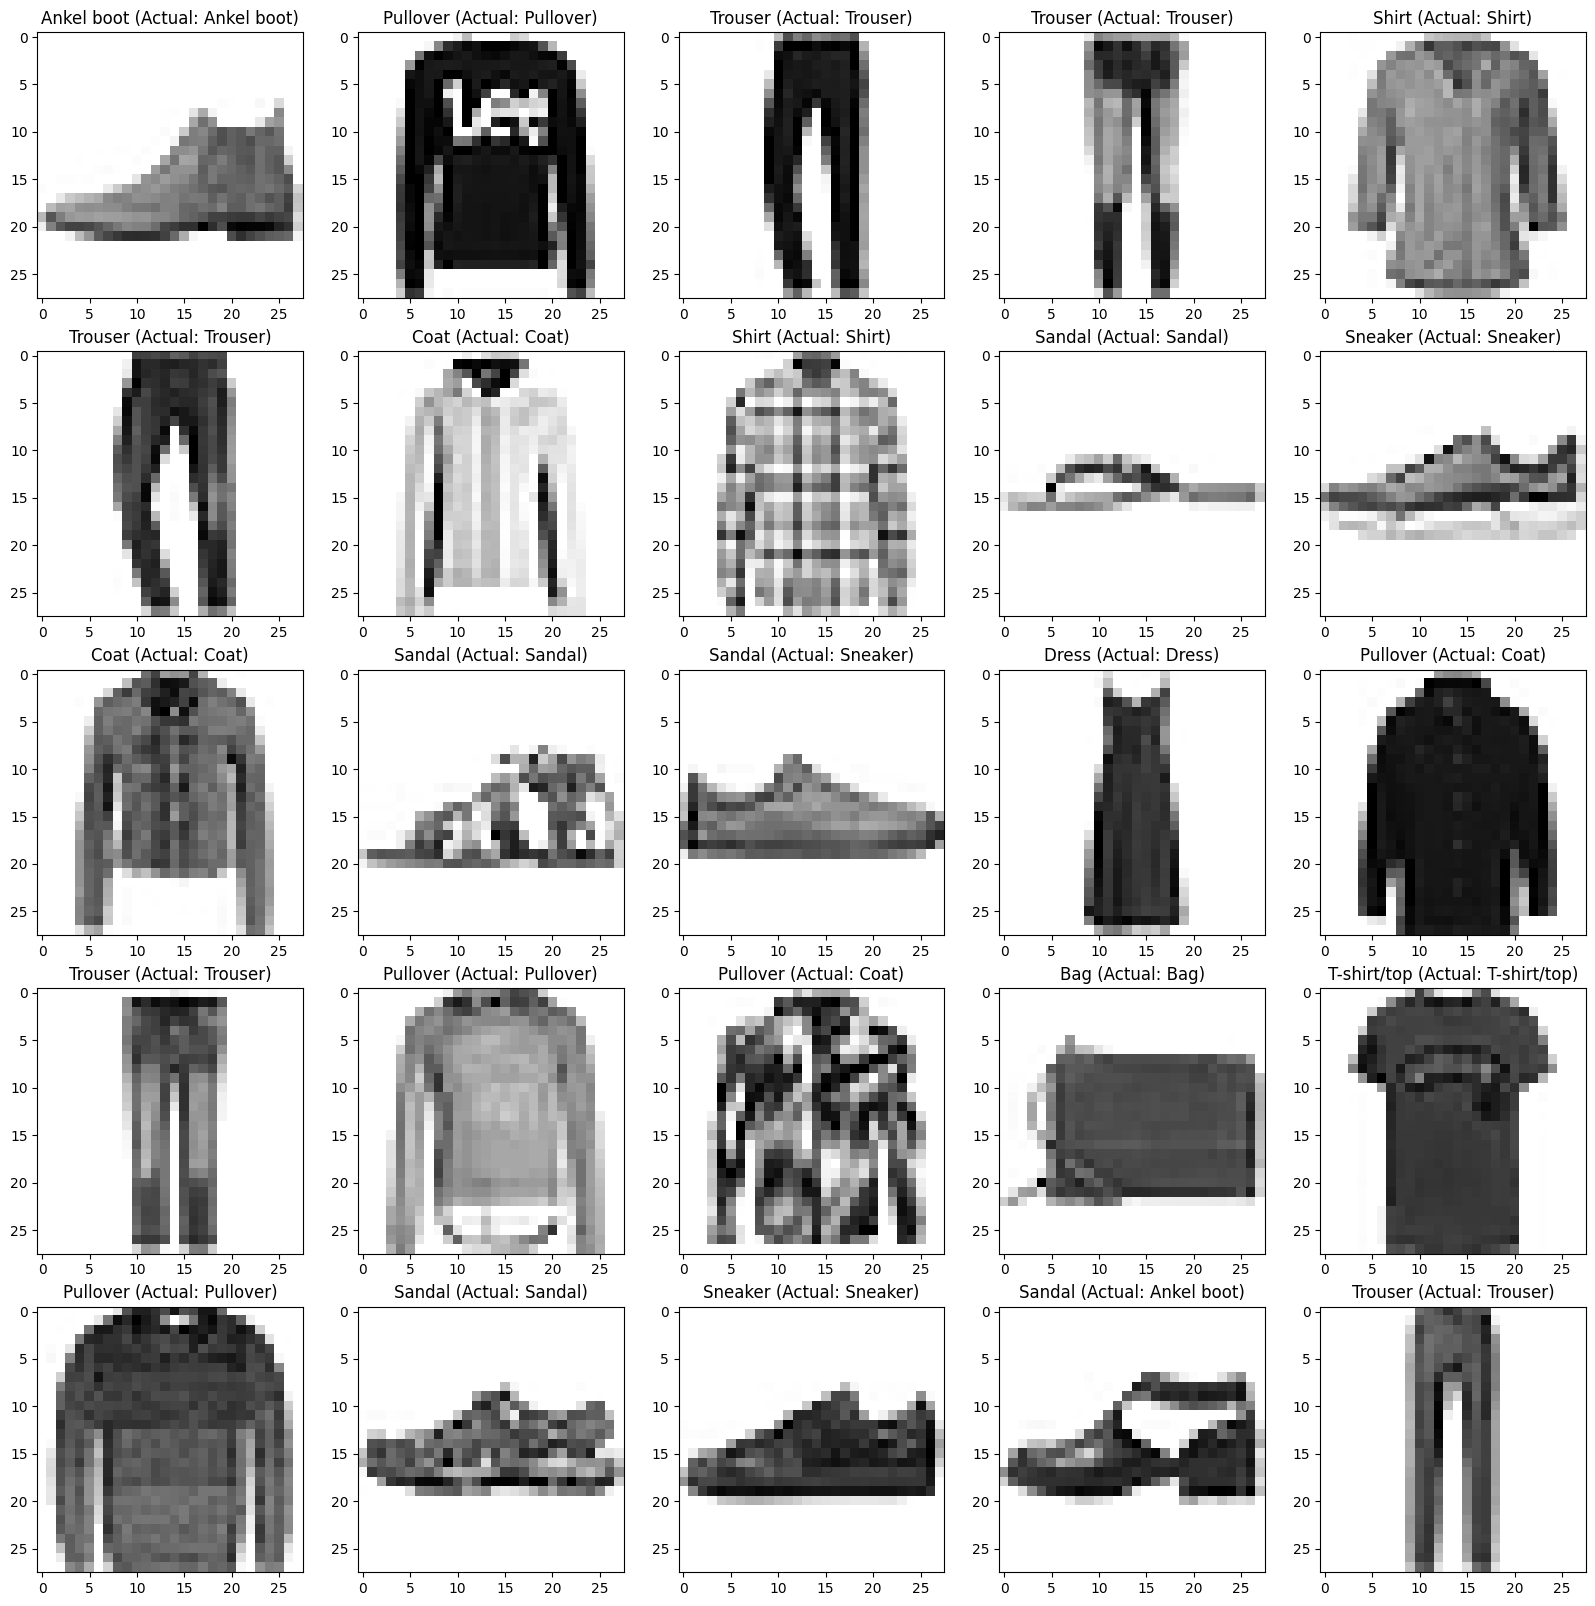

In [79]:
# predict한 범위 시각화
pred = model.predict(x_test[0:25])
fig, axs = plt.subplots(5,5, figsize=(20, 20))
for i in range(5):
  for j in range(5):
    axs[i, j].imshow(x_test[i*5+j].reshape(28,28), cmap='gray_r')
    # 예측한 클래스와 실제 클래스 레이블을 제목으로 표시
    # np.argmax(pred[i*5+j], axis=0) : 예측한 클래스 레이블
    # np.argmax(y_test[i*5+j], axis=0) : 실제 클래스 레이블
    axs[i, j].set_title(items[np.argmax(pred[i*5+j], axis=0)] + ' (Actual: ' + items[np.argmax(y_test[i*5+j], axis=0)] + ')')
plt.show()


## 학습곡선

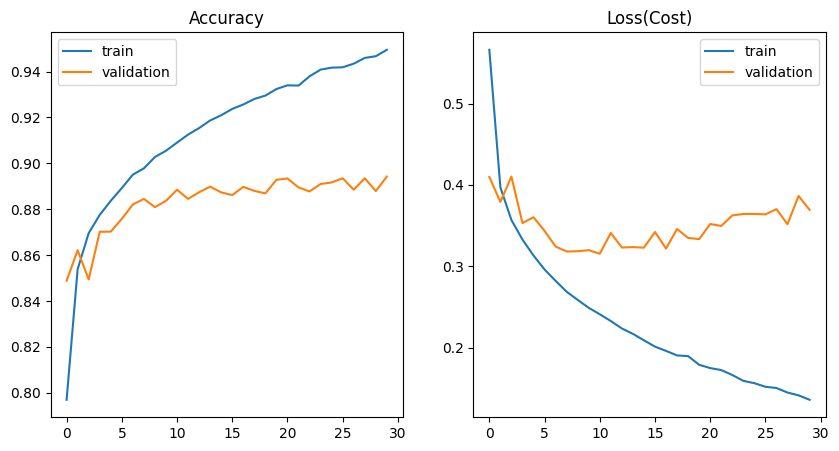

In [80]:
# 학습 과정 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
# 모델 학습 과정에서 기록된 정확도
plt.plot(history.history['accuracy'])
# 모델 학습 과정에서 기록된 검증 정확도
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'validation'])
plt.title('Accuracy')

plt.subplot(1, 2, 2)
# 모델 학습 과정에서 기록된 손실 값
plt.plot(history.history['loss'])
# 모델 학습 과정에서 기록된 검증 손실 값
plt.plot(history.history['val_loss'])
plt.legend(['train', 'validation'])
plt.title('Loss(Cost)')

plt.show()

## 과대적합(Over fitting)/과소적합(Under fitting)

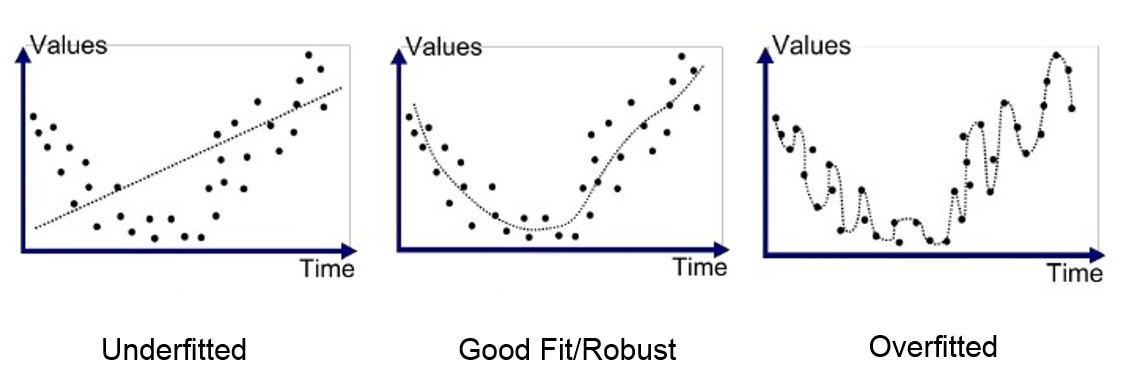

In [81]:
# 드롭아웃 추가
# 드롭아웃은 신경망의 과적합을 방지하기 위해 사용되는 정규화 기법으로,
# 학습 과정에서 무작위로 일부 뉴런을 비활성화하여 모델이 특정 뉴런에 과도하게 의존하는 것을 방지
model1 = models.Sequential([
    layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    layers.Dropout(0.3),  # 드롭아웃 추가
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [83]:
history1 = model1.fit(x_train, y_train, epochs=30, validation_data=(x_val, y_val))

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 670us/step - accuracy: 0.7750 - loss: 0.6182 - val_accuracy: 0.8407 - val_loss: 0.4402
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 612us/step - accuracy: 0.8371 - loss: 0.4474 - val_accuracy: 0.8533 - val_loss: 0.4003
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 605us/step - accuracy: 0.8496 - loss: 0.4111 - val_accuracy: 0.8643 - val_loss: 0.3712
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 616us/step - accuracy: 0.8587 - loss: 0.3828 - val_accuracy: 0.8687 - val_loss: 0.3585
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 603us/step - accuracy: 0.8654 - loss: 0.3645 - val_accuracy: 0.8774 - val_loss: 0.3337
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 617us/step - accuracy: 0.8708 - loss: 0.3486 - val_accuracy: 0.8735 - val_loss: 0.3414
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 607us/step - accuracy: 0.8753 - loss: 0.3385 - val_accuracy: 0.8767 - val_loss: 0.3372
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 618us/step - accuracy: 0.8785 -

In [84]:
model1.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step - accuracy: 0.8873 - loss: 0.3349


[0.33490240573883057, 0.8873000144958496]

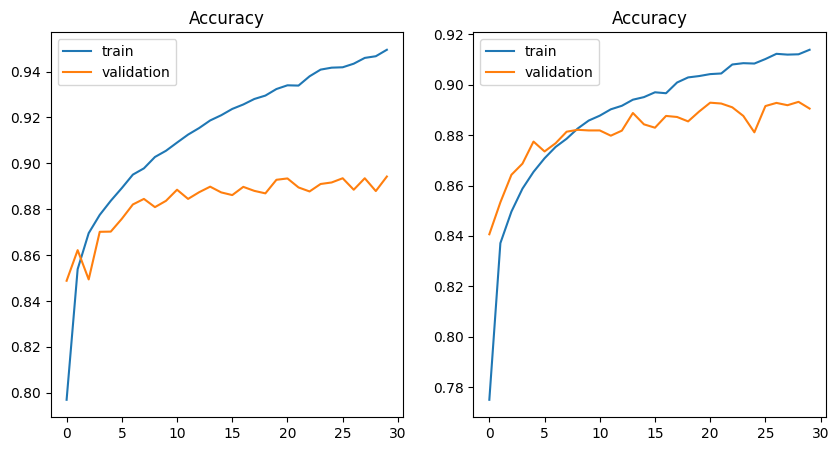

In [88]:
#history, history1 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'validation'])
plt.title('Accuracy')
plt.subplot(1, 2, 2)
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.legend(['train', 'validation'])
plt.title('Accuracy')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


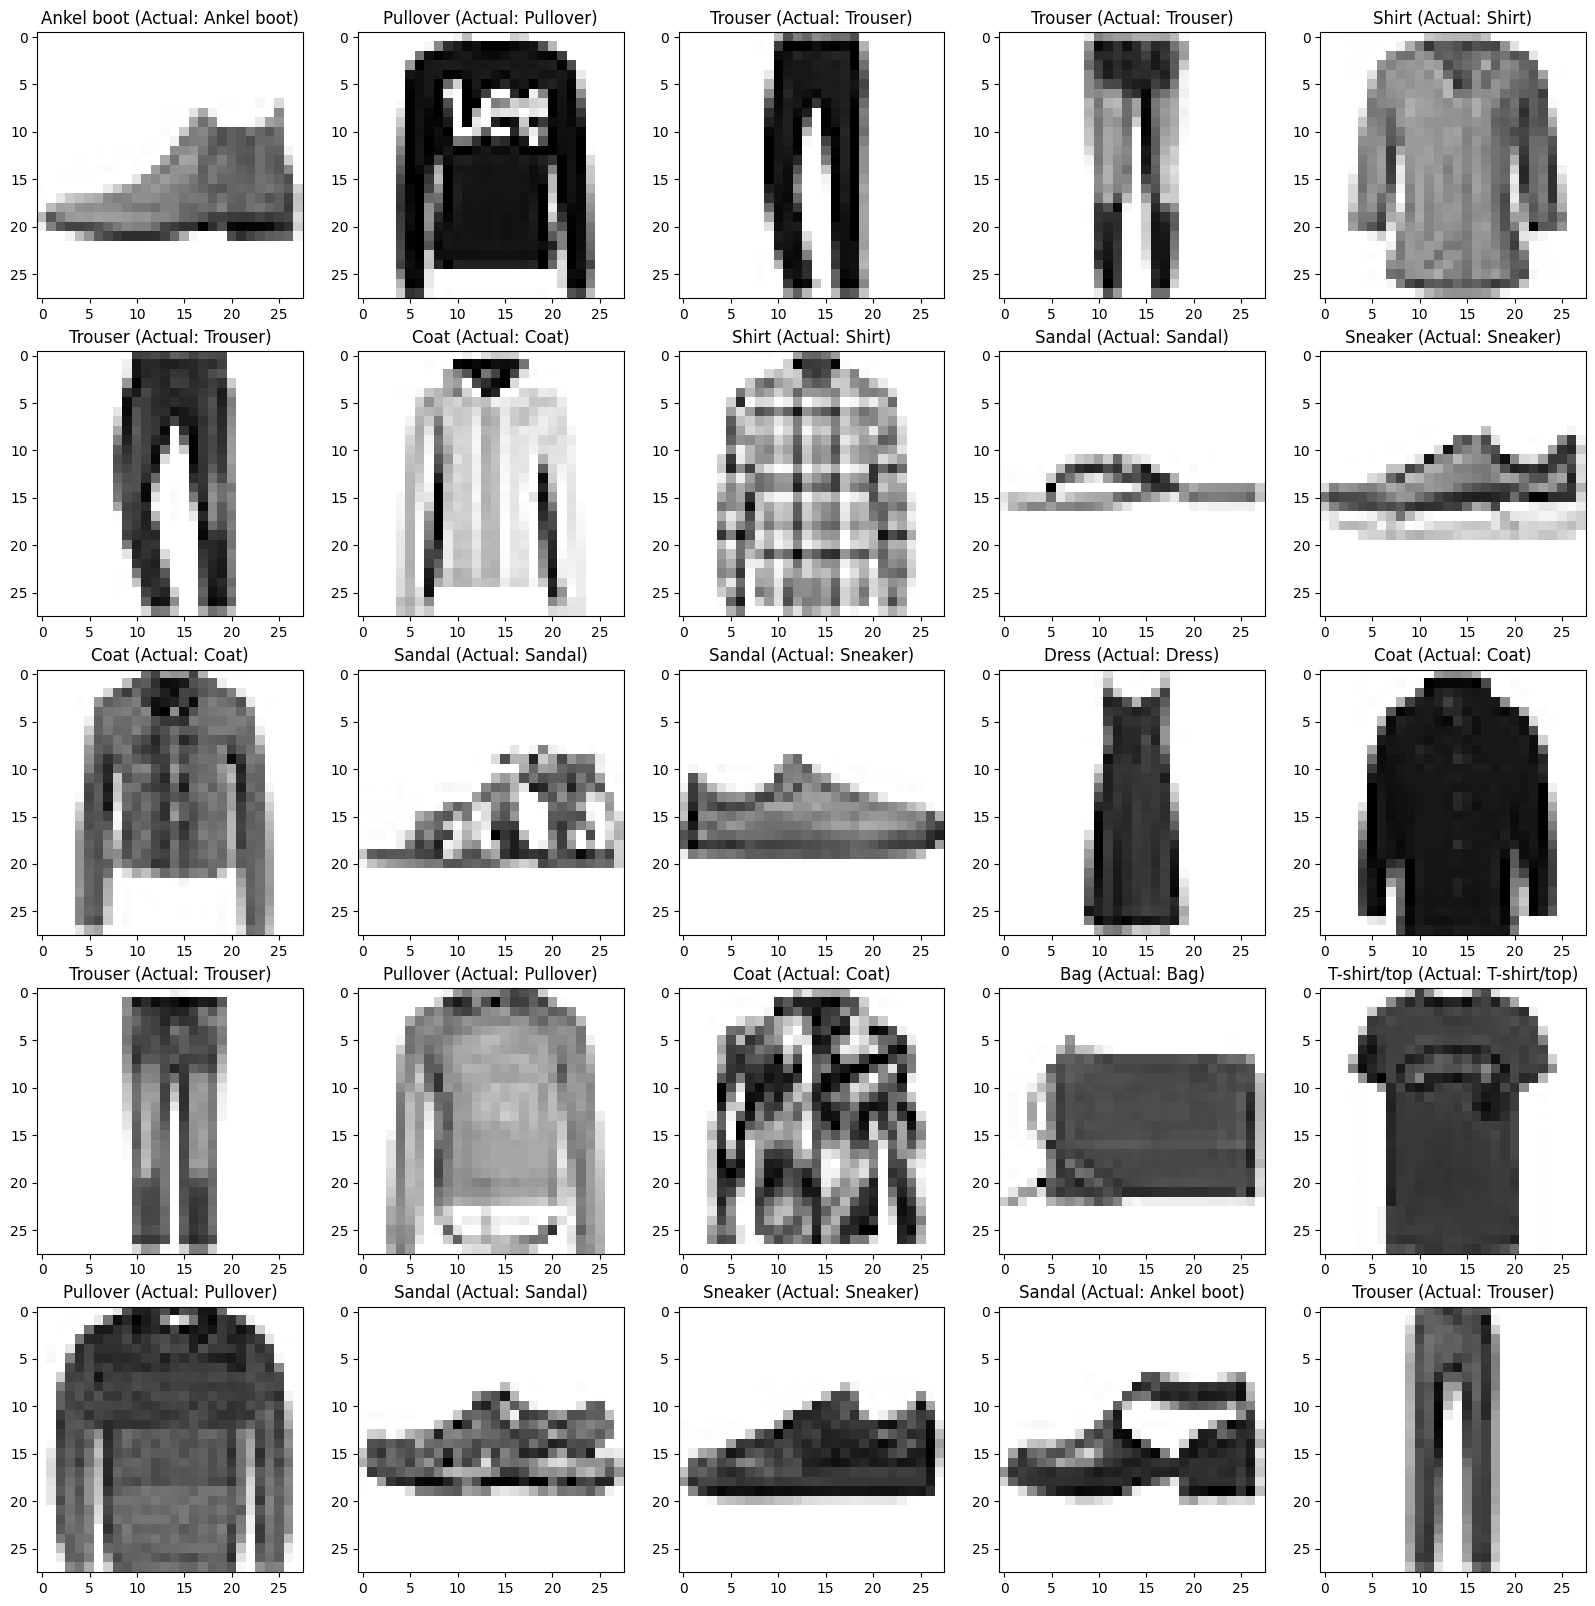

In [89]:
# pred 시각화
pred1 = model1.predict(x_test[0:25])
fig, axs = plt.subplots(5,5, figsize=(20, 20))
for i in range(5):
    for j in range(5):
        axs[i, j].imshow(x_test[i*5+j].reshape(28,28), cmap='gray_r')
        axs[i, j].set_title(items[np.argmax(pred1[i*5+j], axis=0)] + ' (Actual: ' + items[np.argmax(y_test[i*5+j], axis=0)] + ')')
plt.show()

In [90]:
model1.save('fmnist_nn.h5')

In [91]:
model3 = models.load_model('fmnist_nn.h5')
model3.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - accuracy: 0.8873 - loss: 0.3349


[0.33490240573883057, 0.8873000144958496]